# AFFC-Net Training — BRACS Dataset
**AFFC-Net (Base Paper) + SUARA-Inspired Variant (Novelty)**

Trains the full AFFC-Net architecture on BRACS breast cancer dataset (7-class).
All methodology is identical to the LC25000 notebook. Files saved with `ver2` suffix.

**BRACS Classes (7):** 0_N (Normal), 1_PB (Benign), 2_UDH, 3_FEA, 4_ADH, 5_DCIS, 6_IC (Invasive)

In [1]:
import os
import torch

os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # ← change to your GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU   :", torch.cuda.get_device_name(0))

HOME     = os.path.expanduser("~")
MS_BYTES = 8192   # 8 KB SUARA2 segment size

Device: cuda
GPU   : NVIDIA H200


In [2]:
import random, time, copy, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    average_precision_score, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from scipy.stats import friedmanchisquare
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

print("Imports OK")

Imports OK


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

Device: cuda
GPU   : NVIDIA H200
Memory: 150.12 GB


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)
print("Seed fixed to 42")

Seed fixed to 42


In [5]:
# ── Hyperparameters (paper §5.2.4) ────────────────────────────────────────────
NUM_CLASSES  = 7
# Class names match bracs_split_info_ver2.pt class_to_idx:
# {'0_N': 0, '1_PB': 1, '2_UDH': 2, '3_FEA': 3, '4_ADH': 4, '5_DCIS': 5, '6_IC': 6}
CLASS_NAMES  = ["0_N", "1_PB", "2_UDH", "3_FEA", "4_ADH", "5_DCIS", "6_IC"]

BATCH_SIZE   = 32
LR           = 0.01       # SGD learning rate (paper §5.2.4)
WEIGHT_DECAY = 1e-4
NUM_EPOCHS   = 100
PATIENCE     = 20         # early stopping patience

print("Config:")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  LR         : {LR}  |  WD: {WEIGHT_DECAY}")
print(f"  Epochs     : {NUM_EPOCHS}  |  Patience: {PATIENCE}")

Config:
  Classes    : ['0_N', '1_PB', '2_UDH', '3_FEA', '4_ADH', '5_DCIS', '6_IC']
  Batch size : 32
  LR         : 0.01  |  WD: 0.0001
  Epochs     : 100  |  Patience: 20


In [7]:
from torch.serialization import add_safe_globals
add_safe_globals([np._core.multiarray.scalar])

# Load BRACS ver2 features (produced by CNN and GNN extraction notebooks)
cnn_features = torch.load("bracs_cnn_features_ver2.pt", map_location="cpu").float()
gnn_features = torch.load("bracs_gnn_features_ver2.pt", map_location="cpu").float()
labels = torch.load("bracs_cnn_labels_ver2.pt", map_location="cpu").long()

print(f"CNN features : {cnn_features.shape}")
print(f"GNN features : {gnn_features.shape}")
print(f"Labels       : {labels.shape}  unique={torch.unique(labels).tolist()}")
assert cnn_features.shape[1:] == gnn_features.shape[1:], "Shape mismatch CNN vs GNN!"
assert cnn_features.shape[0] == labels.shape[0], "Sample count mismatch!"
print("Load checks passed.")

CNN features : torch.Size([4168, 196, 1024])
GNN features : torch.Size([4159, 196, 1024])
Labels       : torch.Size([4168])  unique=[0, 1, 2, 3, 4, 5, 6]
Load checks passed.


In [8]:
# Verify label distribution (BRACS is imbalanced — weighted loss handles this)
counts = Counter(labels.numpy())
print("Class distribution:", {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})

if len(counts) > NUM_CLASSES:
    # Remove any corrupt label (fewest samples)
    corrupt = min(counts, key=counts.get)
    print(f"Removing corrupt label {corrupt} ({counts[corrupt]} sample(s))")
    mask         = labels != corrupt
    cnn_features = cnn_features[mask]
    gnn_features = gnn_features[mask]
    labels       = labels[mask]
    unique       = sorted(torch.unique(labels).tolist())
    label_map    = {old: new for new, old in enumerate(unique)}
    labels       = torch.tensor([label_map[l.item()] for l in labels], dtype=torch.long)
    print(f"Remapped: {label_map}")
else:
    label_map = {i: i for i in range(NUM_CLASSES)}

TOTAL = len(labels)
print(f"\nFinal: {TOTAL} samples | labels {torch.unique(labels).tolist()}")
assert labels.min() == 0 and labels.max() == NUM_CLASSES - 1
print("Label range verified [0, 6]")

Class distribution: {'0_N': 484, '1_PB': 836, '2_UDH': 322, '3_FEA': 756, '4_ADH': 507, '5_DCIS': 630, '6_IC': 633}

Final: 4168 samples | labels [0, 1, 2, 3, 4, 5, 6]
Label range verified [0, 6]


In [11]:
from sklearn.model_selection import train_test_split

try:
    split_info = torch.load("bracs_split_info_ver2.pt", map_location="cpu",
                            weights_only=False)
    train_end = split_info["train_end"]
    val_end   = split_info["val_end"]
    test_end  = split_info["test_end"]
    print(f"Using saved split: train=0:{train_end}  val={train_end}:{val_end}  test={val_end}:{test_end}")
    train_idx = torch.arange(0, train_end)
    val_idx   = torch.arange(train_end, val_end)
    test_idx  = torch.arange(val_end, test_end)
except Exception as e:
    print(f"split_info not found ({e}), falling back to stratified split")
    all_idx    = np.arange(TOTAL)
    all_labels = labels.numpy()
    TRAIN_SIZE = 3163; VAL_SIZE = 602
    train_idx, temp_idx = train_test_split(
        all_idx, train_size=TRAIN_SIZE, stratify=all_labels, random_state=42)
    val_idx, test_idx = train_test_split(
        temp_idx, train_size=VAL_SIZE,
        stratify=all_labels[temp_idx], random_state=42)
    train_idx = torch.tensor(train_idx)
    val_idx   = torch.tensor(val_idx)
    test_idx  = torch.tensor(test_idx)

# Align all features to minimum sample count (CNN=4168, GNN=4159 mismatch)
min_n        = min(cnn_features.shape[0], gnn_features.shape[0], labels.shape[0])
cnn_features = cnn_features[:min_n]
gnn_features = gnn_features[:min_n]
labels       = labels[:min_n]
print(f"Aligned to {min_n} samples")

# Clip split indices to min_n so no index goes out of bounds
train_idx = train_idx[train_idx < min_n]
val_idx   = val_idx[val_idx < min_n]
test_idx  = test_idx[test_idx < min_n]
print(f"After clip — train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")

train_cnn, val_cnn, test_cnn = cnn_features[train_idx], cnn_features[val_idx], cnn_features[test_idx]
train_gnn, val_gnn, test_gnn = gnn_features[train_idx], gnn_features[val_idx], gnn_features[test_idx]
train_lbl, val_lbl, test_lbl = labels[train_idx],       labels[val_idx],       labels[test_idx]

print(f"Train: {len(train_lbl):,}  Val: {len(val_lbl):,}  Test: {len(test_lbl):,}")
print(f"Train dist: { {CLASS_NAMES[k]:v for k,v in sorted(Counter(train_lbl.numpy()).items())} }")
print(f"Val dist  : { {CLASS_NAMES[k]:v for k,v in sorted(Counter(val_lbl.numpy()).items())} }")
print(f"Test dist : { {CLASS_NAMES[k]:v for k,v in sorted(Counter(test_lbl.numpy()).items())} }")

Using saved split: train=0:3286  val=3286:3598  test=3598:4168
Aligned to 4159 samples
After clip — train=3286  val=312  test=561
Train: 3,286  Val: 312  Test: 561
Train dist: {'0_N': 357, '1_PB': 714, '2_UDH': 194, '3_FEA': 624, '4_ADH': 387, '5_DCIS': 505, '6_IC': 505}
Val dist  : {'0_N': 46, '1_PB': 43, '2_UDH': 46, '3_FEA': 49, '4_ADH': 41, '5_DCIS': 40, '6_IC': 47}
Test dist : {'0_N': 81, '1_PB': 79, '2_UDH': 82, '3_FEA': 83, '4_ADH': 79, '5_DCIS': 85, '6_IC': 72}


In [12]:
class BRACSDataset(Dataset):
    def __init__(self, cnn, gnn, lbl):
        self.cnn = cnn.float()
        self.gnn = gnn.float()
        self.lbl = lbl.long()
    def __len__(self): return len(self.lbl)
    def __getitem__(self, i): return self.cnn[i], self.gnn[i], self.lbl[i]

train_ds = BRACSDataset(train_cnn, train_gnn, train_lbl)
val_ds   = BRACSDataset(val_cnn,   val_gnn,   val_lbl)
test_ds  = BRACSDataset(test_cnn,  test_gnn,  test_lbl)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Loaders: train={len(train_loader)} | val={len(val_loader)} | test={len(test_loader)} batches")

Loaders: train=103 | val=10 | test=18 batches


## Model Architecture
### Attention modules (CBAM-style, paper §4.2 Eq.12–14)

In [13]:
class ChannelAttention(nn.Module):
    """Paper Eq.13: Mc(F) = σ(MLP(AvgPool(F^c)) + MLP(MaxPool(F^c)))"""
    def __init__(self, in_ch, reduction=16):
        super().__init__()
        hidden = max(in_ch // reduction, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_ch, hidden, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, in_ch, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    """Paper Eq.14: Ms(F) = σ(Conv[AvgPool(F^s); MaxPool(F^s)])"""
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

print("ChannelAttention and SpatialAttention defined.")

ChannelAttention and SpatialAttention defined.


In [14]:
class Bottleneck(nn.Module):
    """ResNet-style bottleneck used inside AFF fusion stage."""
    def __init__(self, in_ch, filters, stride=1, dropout=0.2):
        super().__init__()
        f1, f2, f3 = filters
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch, f1, 1, bias=False), nn.BatchNorm2d(f1), nn.ReLU(inplace=True))
        self.conv2 = nn.Sequential(
            nn.Conv2d(f1, f2, 3, padding=1, bias=False), nn.BatchNorm2d(f2), nn.ReLU(inplace=True))
        self.conv3 = nn.Sequential(
            nn.Conv2d(f2, f3, 1, bias=False), nn.BatchNorm2d(f3))
        self.drop  = nn.Dropout2d(p=dropout)
        self.down  = nn.Sequential(
            nn.Conv2d(in_ch, f3, 1, stride=stride, bias=False), nn.BatchNorm2d(f3))
        self.stride = stride
        self.relu   = nn.ReLU(inplace=True)
    def forward(self, x):
        identity = self.down(x)
        out = self.drop(self.conv3(self.conv2(self.conv1(x))))
        if self.stride > 1:
            out = F.avg_pool2d(out, self.stride)
        return self.relu(out + identity)

print("Bottleneck defined.")

Bottleneck defined.


In [15]:
class AFFModule(nn.Module):
    """
    Paper §4.2, Fig.7: Adaptive Feature Fusion module.
    F = μ·C + (1-μ)·G  (Eq.11)
    F' = Ms[Mc(F)·F]·[Mc(F)·F]  (Eq.12)
    Input: CNN tokens [B,196,1024] and GNN tokens [B,196,1024]
    Output: fused spatial map [B, 2048, 7, 7]
    """
    def __init__(self, initial_mu=0.5, reduction=16):
        super().__init__()
        self.mu_raw = nn.Parameter(
            torch.tensor(math.log(initial_mu / (1.0 - initial_mu)), dtype=torch.float32)
        )
        self.cnn_norm = nn.LayerNorm([1024, 14, 14])
        self.gnn_norm = nn.LayerNorm([1024, 14, 14])

        self.ch_att  = ChannelAttention(1024, reduction)
        self.sp_att  = SpatialAttention(kernel_size=7)

        self.fusion = nn.Sequential(
            Bottleneck(1024, [512, 512, 2048], stride=1, dropout=0.2),
            Bottleneck(2048, [512, 512, 2048], stride=1, dropout=0.2),
            Bottleneck(2048, [512, 512, 2048], stride=2, dropout=0.2),  # 14→7
        )

    def tokens_to_map(self, tokens):
        """[B, 196, 1024] → [B, 1024, 14, 14]"""
        B = tokens.shape[0]
        return tokens.view(B, 14, 14, 1024).permute(0, 3, 1, 2).contiguous()

    def forward(self, cnn_tokens, gnn_tokens):
        C = self.cnn_norm(self.tokens_to_map(cnn_tokens))
        G = self.gnn_norm(self.tokens_to_map(gnn_tokens))

        mu = torch.sigmoid(self.mu_raw)
        F  = mu * C + (1.0 - mu) * G            # Eq.11

        mc = self.ch_att(F)                      # Eq.13
        F1 = mc * F
        ms = self.sp_att(F1)                     # Eq.14
        F2 = ms * F1                             # Eq.12

        out = self.fusion(F2)                    # [B, 2048, 7, 7]
        return out, mu

print("AFFModule defined.")

AFFModule defined.


### Graph edge indices
Paper §4.3: after AFF, pixels at same spatial location across channels → graph nodes.

In [16]:
def build_grid_edge_index(h=7, w=7, device="cpu"):
    """
    Full 4-connected grid graph for the 7×7 fused feature map.
    49 nodes, edges between spatially adjacent nodes (up/down/left/right).
    """
    edges = []
    nid = lambda r, c: r * w + c
    for r in range(h):
        for c in range(w):
            if r + 1 < h: edges += [[nid(r,c), nid(r+1,c)], [nid(r+1,c), nid(r,c)]]
            if c + 1 < w: edges += [[nid(r,c), nid(r,c+1)], [nid(r,c+1), nid(r,c)]]
    return torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)


def build_local_edge_index(h=7, w=7, block_size=2, device="cpu"):
    """
    SUARA Step-1 edges: only within local 2×2 spatial blocks.
    Analogy: SUARA process-row sub-allreduce (local subset aggregation).
    """
    edges = []
    nid = lambda r, c: r * w + c
    for br in range(0, h, block_size):
        for bc in range(0, w, block_size):
            block = [(r, c)
                     for r in range(br, min(br + block_size, h))
                     for c in range(bc, min(bc + block_size, w))]
            for i in range(len(block)):
                for j in range(i + 1, len(block)):
                    u = nid(*block[i]); v = nid(*block[j])
                    edges += [[u, v], [v, u]]
    if not edges:
        return torch.zeros((2, 0), dtype=torch.long, device=device)
    return torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)


grid_edge_index  = build_grid_edge_index(7, 7, device=device)
local_edge_index = build_local_edge_index(7, 7, 2, device=device)

print(f"Global grid edge index  : {grid_edge_index.shape}  (49-node full grid)")
print(f"Local block edge index  : {local_edge_index.shape}  (SUARA step-1 partitions)")

Global grid edge index  : torch.Size([2, 168])  (49-node full grid)
Local block edge index  : torch.Size([2, 120])  (SUARA step-1 partitions)


In [17]:
class GraphSAGEClassifier(nn.Module):
    """
    Paper §4.3, Fig.9: N-layer GraphSAGE on the fused graph.
    Input: fused feature map [B, 2048, 7, 7] → 49-node graph.
    Output: class logits [B, num_classes].
    """
    DIMS = {
        1: [2048, 512],
        3: [2048, 1024, 1024, 512],
        5: [2048, 1024, 1024, 1024, 1024, 512],
        7: [2048, 1024, 1024, 1024, 1024, 1024, 1024, 512],
    }
    def __init__(self, num_layers=3, num_classes=7, dropout=0.2):
        super().__init__()
        assert num_layers in self.DIMS, f"num_layers must be one of {list(self.DIMS)}"
        self.dropout = dropout
        dims = self.DIMS[num_layers]
        self.sage_layers = nn.ModuleList([SAGEConv(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        self.bn_layers   = nn.ModuleList([nn.BatchNorm1d(dims[i+1]) for i in range(len(dims)-1)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(dims[-1], num_classes)

    def _map_to_pyg(self, feat_map, edge_index):
        B = feat_map.shape[0]
        nodes = feat_map.permute(0, 2, 3, 1).reshape(B, 49, 2048)
        return Batch.from_data_list([Data(x=nodes[i], edge_index=edge_index) for i in range(B)])

    def forward(self, feat_map, edge_index):
        B     = feat_map.shape[0]
        pyg_b = self._map_to_pyg(feat_map, edge_index)
        x, ei, batch = pyg_b.x, pyg_b.edge_index, pyg_b.batch
        for sage, bn in zip(self.sage_layers, self.bn_layers):
            x = F.relu(bn(sage(x, ei)))
            x = F.dropout(x, p=self.dropout, training=self.training)
        feat_dim = x.shape[-1]
        x = x.view(B, 7, 7, feat_dim).permute(0, 3, 1, 2)
        x = self.pool(x).flatten(1)
        return self.fc(x)

print("GraphSAGEClassifier defined  (supports layers: 1, 3, 5, 7)")

GraphSAGEClassifier defined  (supports layers: 1, 3, 5, 7)


In [18]:
class AFFCNet(nn.Module):
    """Full AFFC-Net: AFF module + GraphSAGE global aggregation."""
    def __init__(self, num_graphsage_layers=3, num_classes=7, initial_mu=0.5):
        super().__init__()
        self.aff       = AFFModule(initial_mu=initial_mu)
        self.graphsage = GraphSAGEClassifier(num_layers=num_graphsage_layers,
                                             num_classes=num_classes, dropout=0.2)
    def forward(self, cnn_tokens, gnn_tokens, edge_index):
        fused, mu = self.aff(cnn_tokens, gnn_tokens)
        return self.graphsage(fused, edge_index), mu

print("AFFCNet defined.")

AFFCNet defined.


### SUARA-Inspired variant
SUARA2 decomposes allreduce into **L=2 serial steps** over process subsets.
Here we analogize this as 2-step hierarchical GraphSAGE aggregation:
- **Step 1 (local)**: aggregate within local 2×2 spatial blocks (process-row sub-allreduce)
- **Step 2 (global)**: aggregate across the full 7×7 grid (process-column sub-allreduce)

In [19]:
class GraphSAGE_SUARA2(nn.Module):
    """
    SUARA2-inspired 2-step hierarchical GraphSAGE aggregation.

    Step 1 (local): SAGEConv on local 2×2 block sub-graphs only.
                    Analogy: SUARA row-subset sub-allreduce.
    Step 2 (global): SAGEConv on full 7×7 grid graph.
                    Analogy: SUARA column-subset sub-allreduce.

    This reduces the effective neighborhood size per step from O(N) to O(√N),
    matching SUARA2's asymptotic speedup of O(√P) over flat allreduce.
    """
    def __init__(self, num_classes=7, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        # Step 1: local aggregation within 2×2 blocks
        self.local_sage1 = SAGEConv(2048, 1024)
        self.local_bn1   = nn.BatchNorm1d(1024)
        self.local_sage2 = SAGEConv(1024, 1024)
        self.local_bn2   = nn.BatchNorm1d(1024)
        # Step 2: global aggregation across full grid
        self.global_sage = SAGEConv(1024, 512)
        self.global_bn   = nn.BatchNorm1d(512)
        # Readout
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(512, num_classes)

    def _map_to_pyg(self, feat_map, edge_index):
        B = feat_map.shape[0]
        nodes = feat_map.permute(0, 2, 3, 1).reshape(B, 49, 2048)
        return Batch.from_data_list([Data(x=nodes[i], edge_index=edge_index) for i in range(B)])

    def forward(self, feat_map, local_ei, global_ei):
        B = feat_map.shape[0]
        local_b  = self._map_to_pyg(feat_map, local_ei)
        global_b = self._map_to_pyg(feat_map, global_ei)

        x    = local_b.x
        l_ei = local_b.edge_index
        g_ei = global_b.edge_index

        # Step 1: local
        x = F.relu(self.local_bn1(self.local_sage1(x, l_ei)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.local_bn2(self.local_sage2(x, l_ei)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Step 2: global
        x = F.relu(self.global_bn(self.global_sage(x, g_ei)))

        # Readout
        x = x.view(B, 7, 7, 512).permute(0, 3, 1, 2)
        x = self.pool(x).flatten(1)
        return self.fc(x)


class AFFCNet_SUARA(nn.Module):
    """AFFC-Net with SUARA2-inspired hierarchical aggregation (novelty)."""
    def __init__(self, num_classes=7, initial_mu=0.5):
        super().__init__()
        self.aff       = AFFModule(initial_mu=initial_mu)
        self.graphsage = GraphSAGE_SUARA2(num_classes=num_classes, dropout=0.2)

    def forward(self, cnn_tokens, gnn_tokens, local_ei, global_ei):
        fused, mu = self.aff(cnn_tokens, gnn_tokens)
        logits    = self.graphsage(fused, local_ei, global_ei)
        return logits, mu

print("AFFCNet_SUARA (novelty) defined.")

AFFCNet_SUARA (novelty) defined.


### Ablation models
Match paper Table 1 ablation rows: AFFC-Net without GNN, without AFF.

In [20]:
class AFFCNetNoGNN(nn.Module):
    """Ablation: CNN branch only. GNN tokens zeroed out, mu fixed to 1."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.aff       = AFFModule(initial_mu=0.5)
        self.graphsage = GraphSAGEClassifier(num_layers=3, num_classes=num_classes, dropout=0.2)
    def forward(self, cnn_tokens, gnn_tokens, edge_index):
        C  = self.aff.tokens_to_map(cnn_tokens)
        mc = self.aff.ch_att(C)
        F1 = mc * C
        ms = self.aff.sp_att(F1)
        F2 = ms * F1
        return self.graphsage(self.aff.fusion(F2), edge_index), torch.tensor(1.0)


class AFFCNetNoAFF(nn.Module):
    """Ablation: no attention — plain adaptive weighted sum only, no CBAM."""
    def __init__(self, num_classes=7):
        super().__init__()
        self.mu_raw = nn.Parameter(torch.tensor(0.0))
        self.cnn_norm = nn.LayerNorm([1024, 14, 14])
        self.gnn_norm = nn.LayerNorm([1024, 14, 14])
        self.fusion   = nn.Sequential(
            Bottleneck(1024, [512, 512, 2048], stride=1, dropout=0.2),
            Bottleneck(2048, [512, 512, 2048], stride=1, dropout=0.2),
            Bottleneck(2048, [512, 512, 2048], stride=2, dropout=0.2),
        )
        self.graphsage = GraphSAGEClassifier(num_layers=3, num_classes=num_classes, dropout=0.2)
    def _tok2map(self, t):
        return t.view(t.shape[0], 14, 14, 1024).permute(0, 3, 1, 2).contiguous()
    def forward(self, cnn_tokens, gnn_tokens, edge_index):
        C  = self.cnn_norm(self._tok2map(cnn_tokens))
        G  = self.gnn_norm(self._tok2map(gnn_tokens))
        mu = torch.sigmoid(self.mu_raw)
        F  = mu * C + (1.0 - mu) * G
        return self.graphsage(self.fusion(F), edge_index), mu

print("Ablation models defined (NoGNN, NoAFF).")

Ablation models defined (NoGNN, NoAFF).


In [21]:
model_3layer = AFFCNet(num_graphsage_layers=3, num_classes=NUM_CLASSES).to(device)
model_5layer = AFFCNet(num_graphsage_layers=5, num_classes=NUM_CLASSES).to(device)
model_no_gnn = AFFCNetNoGNN(num_classes=NUM_CLASSES).to(device)
model_no_aff = AFFCNetNoAFF(num_classes=NUM_CLASSES).to(device)
model_suara  = AFFCNet_SUARA(num_classes=NUM_CLASSES).to(device)

for name, m in [("3-layer", model_3layer), ("5-layer", model_5layer),
                ("no-GNN",  model_no_gnn), ("no-AFF",  model_no_aff),
                ("SUARA",   model_suara)]:
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {name:<10}: {n_params:>10,} params")

# Sanity check forward pass
with torch.no_grad():
    cb, gb, lb = next(iter(train_loader))
    cb, gb = cb.to(device), gb.to(device)
    out3, mu3 = model_3layer(cb, gb, grid_edge_index)
    outs, mus = model_suara(cb, gb, local_edge_index, grid_edge_index)
    print(f"\n3-layer forward: logits={out3.shape}  mu={mu3.item():.4f}")
    print(f"SUARA   forward: logits={outs.shape}  mu={mus.item():.4f}")
    assert out3.shape == (lb.shape[0], NUM_CLASSES)
print("All forward passes OK.")

  3-layer   : 31,646,826 params
  5-layer   : 35,847,274 params
  no-GNN    : 31,646,826 params
  no-AFF    : 31,515,656 params
  SUARA     : 31,646,826 params

3-layer forward: logits=torch.Size([32, 7])  mu=0.5000
SUARA   forward: logits=torch.Size([32, 7])  mu=0.5000
All forward passes OK.


In [22]:
# BRACS is imbalanced — weighted CrossEntropyLoss is important here
def compute_class_weights(labels, num_classes):
    counts  = torch.bincount(labels, minlength=num_classes).float()
    weights = counts.sum() / (num_classes * counts.clamp(min=1.0))
    return weights

class_weights = compute_class_weights(train_lbl, NUM_CLASSES).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:", {CLASS_NAMES[i]: round(class_weights[i].item(), 4) for i in range(NUM_CLASSES)})

Class weights: {'0_N': 1.3149, '1_PB': 0.6575, '2_UDH': 2.4197, '3_FEA': 0.7523, '4_ADH': 1.213, '5_DCIS': 0.9296, '6_IC': 0.9296}


In [23]:
def compute_specificity(cm):
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - (tp + fn + fp)
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return np.array(specs)

def evaluate_predictions(y_true, y_pred, y_prob):
    cm    = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
    specs = compute_specificity(cm)
    return {
        "weighted_f1"      : f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "per_class_f1"     : f1_score(y_true, y_pred, average=None,       zero_division=0),
        "accuracy"         : (np.array(y_true) == np.array(y_pred)).mean(),
        "precision_w"      : precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_w"         : recall_score(y_true,    y_pred, average="weighted", zero_division=0),
        "specificity_macro": specs.mean(),
        "specificity"      : specs,
        "confusion_matrix" : cm,
        "y_true": np.array(y_true), "y_pred": np.array(y_pred), "y_prob": np.array(y_prob),
        "report": classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)
    }

print("Metrics helpers ready.")

Metrics helpers ready.


In [24]:
def train_epoch(model, loader, criterion, optimizer, edge_index,
                suara_local_ei=None, suara_global_ei=None, is_suara=False):
    """
    Unified train epoch for all model variants.
    Returns metrics dict including epoch_time and throughput (for SUARA comparison).
    """
    model.train()
    total_loss = total_n = 0
    all_preds, all_true, all_probs = [], [], []
    t_start = time.time()

    for cnn_b, gnn_b, lbl_b in loader:
        cnn_b = cnn_b.to(device, non_blocking=True)
        gnn_b = gnn_b.to(device, non_blocking=True)
        lbl_b = lbl_b.to(device, non_blocking=True)
        optimizer.zero_grad()
        if is_suara:
            logits, mu = model(cnn_b, gnn_b, suara_local_ei, suara_global_ei)
        else:
            logits, mu = model(cnn_b, gnn_b, edge_index)
        loss = criterion(logits, lbl_b)
        loss.backward()
        optimizer.step()
        bs = lbl_b.size(0)
        total_loss += loss.item() * bs; total_n += bs
        all_probs.append(F.softmax(logits, dim=1).detach().cpu().numpy())
        all_preds.append(logits.argmax(1).detach().cpu().numpy())
        all_true.append(lbl_b.cpu().numpy())

    epoch_time = time.time() - t_start
    m = evaluate_predictions(
        np.concatenate(all_true), np.concatenate(all_preds), np.concatenate(all_probs))
    m["loss"]       = total_loss / total_n
    m["mu"]         = mu.item()
    m["epoch_time"] = epoch_time
    m["throughput"] = total_n / epoch_time
    return m


@torch.no_grad()
def eval_epoch(model, loader, criterion, edge_index,
               suara_local_ei=None, suara_global_ei=None, is_suara=False):
    model.eval()
    total_loss = total_n = 0
    all_preds, all_true, all_probs = [], [], []
    for cnn_b, gnn_b, lbl_b in loader:
        cnn_b = cnn_b.to(device, non_blocking=True)
        gnn_b = gnn_b.to(device, non_blocking=True)
        lbl_b = lbl_b.to(device, non_blocking=True)
        if is_suara:
            logits, mu = model(cnn_b, gnn_b, suara_local_ei, suara_global_ei)
        else:
            logits, mu = model(cnn_b, gnn_b, edge_index)
        loss = criterion(logits, lbl_b)
        bs = lbl_b.size(0)
        total_loss += loss.item() * bs; total_n += bs
        all_probs.append(F.softmax(logits, dim=1).cpu().numpy())
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_true.append(lbl_b.cpu().numpy())
    m = evaluate_predictions(
        np.concatenate(all_true), np.concatenate(all_preds), np.concatenate(all_probs))
    m["loss"] = total_loss / total_n
    m["mu"]   = mu.item()
    return m

print("train_epoch / eval_epoch ready (with timing instrumentation).")

train_epoch / eval_epoch ready (with timing instrumentation).


In [25]:
import os
def train_affcnet(model, model_name, save_path, checkpoint_path=None,
                  edge_index=None, is_suara=False,
                  suara_local_ei=None, suara_global_ei=None):
    """
    Universal training loop for all model variants.
    Tracks epoch_time and throughput for SUARA efficiency comparison.
    """
    if edge_index is None:
        edge_index = grid_edge_index

    optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                                momentum=0.9, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-5)

    best_val_f1 = -1.0; best_state = None; patience_ctr = 0; start_epoch = 1
    history = {k: [] for k in ["epoch", "train_loss", "val_loss", "train_f1",
                                "val_f1", "train_acc", "val_acc", "mu",
                                "epoch_time", "throughput"]}

    if checkpoint_path and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        best_val_f1 = ckpt["best_val_f1"]; patience_ctr = ckpt["patience_counter"]
        start_epoch = ckpt["epoch"] + 1;   history = ckpt["history"]
        if os.path.exists(save_path):
            best_state = torch.load(save_path, map_location=device, weights_only=True)
        print(f"Resumed {model_name} from epoch {start_epoch}  best F1={best_val_f1:.4f}")
    else:
        print(f"Starting {model_name} from scratch")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        train_m = train_epoch(model, train_loader, criterion, optimizer,
                              edge_index, suara_local_ei, suara_global_ei, is_suara)
        val_m   = eval_epoch(model, val_loader, criterion,
                             edge_index, suara_local_ei, suara_global_ei, is_suara)
        scheduler.step(val_m["weighted_f1"])

        for k in ["epoch", "train_loss", "val_loss", "train_f1", "val_f1",
                  "train_acc", "val_acc", "mu", "epoch_time", "throughput"]:
            history[k].append({
                "epoch": epoch, "train_loss": train_m["loss"],
                "val_loss": val_m["loss"], "train_f1": train_m["weighted_f1"],
                "val_f1": val_m["weighted_f1"], "train_acc": train_m["accuracy"],
                "val_acc": val_m["accuracy"], "mu": train_m["mu"],
                "epoch_time": train_m["epoch_time"],
                "throughput": train_m["throughput"]
            }[k])

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"{model_name} | Ep {epoch:03d} | "
              f"Loss={train_m['loss']:.4f} | TrainF1={train_m['weighted_f1']:.4f} | "
              f"ValF1={val_m['weighted_f1']:.4f} | mu={train_m['mu']:.4f} | "
              f"lr={lr_now:.5f} | {train_m['epoch_time']:.1f}s | "
              f"{train_m['throughput']:.0f} img/s")

        if val_m["weighted_f1"] > best_val_f1:
            best_val_f1 = val_m["weighted_f1"]; patience_ctr = 0
            best_state  = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            print(f"  ✓ Best saved. ValF1={best_val_f1:.4f}")
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"  Early stop at epoch {epoch}"); break

        if checkpoint_path:
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "optimizer_state": optimizer.state_dict(),
                        "scheduler_state": scheduler.state_dict(),
                        "best_val_f1": best_val_f1,
                        "patience_counter": patience_ctr, "history": history
                        }, checkpoint_path)

    model.load_state_dict(best_state)
    return model, history, best_val_f1

print("train_affcnet loop ready.")

train_affcnet loop ready.


## Train AFFCNet-3Layer

In [26]:
trained_3layer, history_3layer, best_f1_3layer = train_affcnet(
    model=model_3layer,
    model_name="AFFCNet-3Layer",
    save_path="affcnet_bracs_3layer_best_ver2.pt",
    checkpoint_path="affcnet_bracs_3layer_ckpt_ver2.pt",
    edge_index=grid_edge_index
)

Starting AFFCNet-3Layer from scratch
AFFCNet-3Layer | Ep 001 | Loss=1.2888 | TrainF1=0.5309 | ValF1=0.5595 | mu=0.6828 | lr=0.01000 | 4.8s | 681 img/s
  ✓ Best saved. ValF1=0.5595
AFFCNet-3Layer | Ep 002 | Loss=0.8663 | TrainF1=0.6901 | ValF1=0.5795 | mu=0.7528 | lr=0.01000 | 4.4s | 746 img/s
  ✓ Best saved. ValF1=0.5795
AFFCNet-3Layer | Ep 003 | Loss=0.7101 | TrainF1=0.7439 | ValF1=0.5714 | mu=0.7857 | lr=0.01000 | 4.3s | 765 img/s
AFFCNet-3Layer | Ep 004 | Loss=0.6520 | TrainF1=0.7644 | ValF1=0.5657 | mu=0.8005 | lr=0.01000 | 4.2s | 775 img/s
AFFCNet-3Layer | Ep 005 | Loss=0.5132 | TrainF1=0.7992 | ValF1=0.6063 | mu=0.8065 | lr=0.01000 | 4.7s | 693 img/s
  ✓ Best saved. ValF1=0.6063
AFFCNet-3Layer | Ep 006 | Loss=0.4930 | TrainF1=0.7993 | ValF1=0.6021 | mu=0.8200 | lr=0.01000 | 4.7s | 706 img/s
AFFCNet-3Layer | Ep 007 | Loss=0.3705 | TrainF1=0.8577 | ValF1=0.5275 | mu=0.8245 | lr=0.01000 | 4.4s | 741 img/s
AFFCNet-3Layer | Ep 008 | Loss=0.3954 | TrainF1=0.8516 | ValF1=0.5384 | mu=0.8

## Train AFFCNet-5Layer

In [27]:
trained_5layer, history_5layer, best_f1_5layer = train_affcnet(
    model=model_5layer,
    model_name="AFFCNet-5Layer",
    save_path="affcnet_bracs_5layer_best_ver2.pt",
    checkpoint_path="affcnet_bracs_5layer_ckpt_ver2.pt",
    edge_index=grid_edge_index
)

Starting AFFCNet-5Layer from scratch
AFFCNet-5Layer | Ep 001 | Loss=1.4045 | TrainF1=0.4759 | ValF1=0.5503 | mu=0.6777 | lr=0.01000 | 4.3s | 756 img/s
  ✓ Best saved. ValF1=0.5503
AFFCNet-5Layer | Ep 002 | Loss=0.9858 | TrainF1=0.6619 | ValF1=0.5826 | mu=0.7521 | lr=0.01000 | 4.6s | 713 img/s
  ✓ Best saved. ValF1=0.5826
AFFCNet-5Layer | Ep 003 | Loss=0.7901 | TrainF1=0.7176 | ValF1=0.5638 | mu=0.7794 | lr=0.01000 | 4.6s | 719 img/s
AFFCNet-5Layer | Ep 004 | Loss=0.6911 | TrainF1=0.7465 | ValF1=0.5601 | mu=0.7893 | lr=0.01000 | 4.7s | 695 img/s
AFFCNet-5Layer | Ep 005 | Loss=0.6397 | TrainF1=0.7715 | ValF1=0.5388 | mu=0.8161 | lr=0.01000 | 5.3s | 615 img/s
AFFCNet-5Layer | Ep 006 | Loss=0.5592 | TrainF1=0.7913 | ValF1=0.5460 | mu=0.8171 | lr=0.01000 | 4.6s | 715 img/s
AFFCNet-5Layer | Ep 007 | Loss=0.4953 | TrainF1=0.8085 | ValF1=0.5259 | mu=0.8277 | lr=0.01000 | 4.3s | 756 img/s
AFFCNet-5Layer | Ep 008 | Loss=0.4817 | TrainF1=0.8194 | ValF1=0.5819 | mu=0.8388 | lr=0.01000 | 4.5s | 738

## Train ablation: No-GNN

In [28]:
trained_nognn, history_nognn, best_f1_nognn = train_affcnet(
    model=model_no_gnn, model_name="AFFCNet-NoGNN",
    save_path="affcnet_bracs_nognn_best_ver2.pt",
    checkpoint_path="affcnet_bracs_nognn_ckpt_ver2.pt", edge_index=grid_edge_index
)

Starting AFFCNet-NoGNN from scratch
AFFCNet-NoGNN | Ep 001 | Loss=1.1805 | TrainF1=0.5740 | ValF1=0.5387 | mu=1.0000 | lr=0.01000 | 4.6s | 716 img/s
  ✓ Best saved. ValF1=0.5387
AFFCNet-NoGNN | Ep 002 | Loss=0.8041 | TrainF1=0.7130 | ValF1=0.5915 | mu=1.0000 | lr=0.01000 | 3.7s | 883 img/s
  ✓ Best saved. ValF1=0.5915
AFFCNet-NoGNN | Ep 003 | Loss=0.6695 | TrainF1=0.7570 | ValF1=0.5731 | mu=1.0000 | lr=0.01000 | 3.8s | 865 img/s
AFFCNet-NoGNN | Ep 004 | Loss=0.6385 | TrainF1=0.7624 | ValF1=0.5424 | mu=1.0000 | lr=0.01000 | 3.9s | 848 img/s
AFFCNet-NoGNN | Ep 005 | Loss=0.5490 | TrainF1=0.7942 | ValF1=0.5902 | mu=1.0000 | lr=0.01000 | 3.9s | 833 img/s
AFFCNet-NoGNN | Ep 006 | Loss=0.4561 | TrainF1=0.8246 | ValF1=0.4827 | mu=1.0000 | lr=0.01000 | 3.7s | 878 img/s
AFFCNet-NoGNN | Ep 007 | Loss=0.3935 | TrainF1=0.8494 | ValF1=0.5430 | mu=1.0000 | lr=0.01000 | 3.4s | 977 img/s
AFFCNet-NoGNN | Ep 008 | Loss=0.3393 | TrainF1=0.8683 | ValF1=0.5221 | mu=1.0000 | lr=0.01000 | 3.7s | 882 img/s
AF

## Train ablation: No-AFF

In [29]:
trained_noaff, history_noaff, best_f1_noaff = train_affcnet(
    model=model_no_aff, model_name="AFFCNet-NoAFF",
    save_path="affcnet_bracs_noaff_best_ver2.pt",
    checkpoint_path="affcnet_bracs_noaff_ckpt_ver2.pt", edge_index=grid_edge_index
)

Starting AFFCNet-NoAFF from scratch
AFFCNet-NoAFF | Ep 001 | Loss=1.2858 | TrainF1=0.5361 | ValF1=0.5720 | mu=0.7049 | lr=0.01000 | 3.6s | 907 img/s
  ✓ Best saved. ValF1=0.5720
AFFCNet-NoAFF | Ep 002 | Loss=0.8643 | TrainF1=0.6868 | ValF1=0.5848 | mu=0.7737 | lr=0.01000 | 4.2s | 791 img/s
  ✓ Best saved. ValF1=0.5848
AFFCNet-NoAFF | Ep 003 | Loss=0.7042 | TrainF1=0.7505 | ValF1=0.6024 | mu=0.8058 | lr=0.01000 | 3.7s | 899 img/s
  ✓ Best saved. ValF1=0.6024
AFFCNet-NoAFF | Ep 004 | Loss=0.5685 | TrainF1=0.7821 | ValF1=0.5888 | mu=0.8244 | lr=0.01000 | 3.7s | 883 img/s
AFFCNet-NoAFF | Ep 005 | Loss=0.4994 | TrainF1=0.7986 | ValF1=0.5973 | mu=0.8350 | lr=0.01000 | 3.9s | 840 img/s
AFFCNet-NoAFF | Ep 006 | Loss=0.4605 | TrainF1=0.8197 | ValF1=0.5607 | mu=0.8390 | lr=0.01000 | 3.8s | 861 img/s
AFFCNet-NoAFF | Ep 007 | Loss=0.3821 | TrainF1=0.8462 | ValF1=0.5898 | mu=0.8452 | lr=0.01000 | 3.8s | 872 img/s
AFFCNet-NoAFF | Ep 008 | Loss=0.3060 | TrainF1=0.8819 | ValF1=0.6373 | mu=0.8474 | lr=

## Train SUARA variant (novelty)

In [30]:
trained_suara, history_suara, best_f1_suara = train_affcnet(
    model=model_suara, model_name="AFFCNet-SUARA",
    save_path="affcnet_bracs_suara_best_ver2.pt",
    checkpoint_path="affcnet_bracs_suara_ckpt_ver2.pt",
    is_suara=True,
    suara_local_ei=local_edge_index,
    suara_global_ei=grid_edge_index
)

Starting AFFCNet-SUARA from scratch
AFFCNet-SUARA | Ep 001 | Loss=1.2749 | TrainF1=0.5427 | ValF1=0.5470 | mu=0.7043 | lr=0.01000 | 4.8s | 690 img/s
  ✓ Best saved. ValF1=0.5470
AFFCNet-SUARA | Ep 002 | Loss=0.9124 | TrainF1=0.6763 | ValF1=0.5473 | mu=0.7581 | lr=0.01000 | 4.9s | 675 img/s
  ✓ Best saved. ValF1=0.5473
AFFCNet-SUARA | Ep 003 | Loss=0.7010 | TrainF1=0.7438 | ValF1=0.5722 | mu=0.7710 | lr=0.01000 | 4.6s | 716 img/s
  ✓ Best saved. ValF1=0.5722
AFFCNet-SUARA | Ep 004 | Loss=0.6229 | TrainF1=0.7706 | ValF1=0.5909 | mu=0.7913 | lr=0.01000 | 4.7s | 699 img/s
  ✓ Best saved. ValF1=0.5909
AFFCNet-SUARA | Ep 005 | Loss=0.5307 | TrainF1=0.8021 | ValF1=0.5820 | mu=0.8072 | lr=0.01000 | 4.5s | 733 img/s
AFFCNet-SUARA | Ep 006 | Loss=0.4843 | TrainF1=0.8130 | ValF1=0.5345 | mu=0.8200 | lr=0.01000 | 4.5s | 737 img/s
AFFCNet-SUARA | Ep 007 | Loss=0.4252 | TrainF1=0.8376 | ValF1=0.5193 | mu=0.8285 | lr=0.01000 | 4.6s | 717 img/s
AFFCNet-SUARA | Ep 008 | Loss=0.4343 | TrainF1=0.8362 | V

## Resume helper (run if kernel crashes)

In [ ]:
# Re-instantiate and reload from checkpoints if kernel died
for model_obj, ckpt, name in [
    (model_3layer, "affcnet_bracs_3layer_ckpt_ver2.pt",  "3-layer"),
    (model_5layer, "affcnet_bracs_5layer_ckpt_ver2.pt",  "5-layer"),
    (model_no_gnn, "affcnet_bracs_nognn_ckpt_ver2.pt",   "no-gnn"),
    (model_no_aff, "affcnet_bracs_noaff_ckpt_ver2.pt",   "no-aff"),
    (model_suara,  "affcnet_bracs_suara_ckpt_ver2.pt",   "suara"),
]:
    if os.path.exists(ckpt):
        c = torch.load(ckpt, map_location=device, weights_only=False)
        model_obj.load_state_dict(c["model_state"])
        print(f"{name}: ep={c['epoch']}  best_F1={c['best_val_f1']:.4f}")
    else:
        print(f"{name}: no checkpoint")

## Test set evaluation — all models

In [31]:
print("Evaluating all models on test set...")

test_3layer = eval_epoch(trained_3layer, test_loader, criterion, grid_edge_index)
test_5layer = eval_epoch(trained_5layer, test_loader, criterion, grid_edge_index)

test_nognn  = eval_epoch(trained_nognn,  test_loader, criterion, grid_edge_index)
test_noaff  = eval_epoch(trained_noaff,  test_loader, criterion, grid_edge_index)
test_suara  = eval_epoch(trained_suara,  test_loader, criterion, grid_edge_index,
                         suara_local_ei=local_edge_index,
                         suara_global_ei=grid_edge_index, is_suara=True)

print("All test evaluations complete.")

Evaluating all models on test set...
All test evaluations complete.


## Paper Table 1 reproduction — BRACS weighted F1 per class
Paper reports: Normal=68.79, Benign=62.13, UDH=45.32, FEA=82.35, ADH=61.56, DCIS=66.63, Invasive=83.84  Weighted F1=67.23%

In [45]:
print("=" * 100)
header = f"{'Model':<28} {'0_N':>7} {'1_PB':>7} {'2_UDH':>7} {'3_FEA':>7} {'4_ADH':>7} {'5_DCIS':>7} {'6_IC':>7} {'WtdF1':>7}"
print(header)
print("-" * 100)
rows = [
    ("AFFC-NoGNN (ablation)",   test_nognn),
    ("AFFC-NoAFF (ablation)",   test_noaff),
    ("AFFCNet-3Layer (paper)",  test_3layer),
    ("AFFCNet-5Layer",          test_5layer),
    ("AFFCNet-SUARA (ours)",    test_suara),
]
for name, m in rows:
    pcf = m["per_class_f1"] * 100
    # pad if fewer classes returned
    while len(pcf) < NUM_CLASSES:
        pcf = np.append(pcf, 0.0)
    print(f"{name:<28} "
          + " ".join(f"{v:>6.2f}%" for v in pcf[:NUM_CLASSES])
          + f" {m['weighted_f1']*100:>6.2f}%")
print("-" * 100)
# Paper target row


Model                            0_N    1_PB   2_UDH   3_FEA   4_ADH  5_DCIS    6_IC   WtdF1
----------------------------------------------------------------------------------------------------
AFFC-NoGNN (ablation)         73.05%  38.22%  23.53%  69.77%  37.61%  35.82%  74.82%  50.02%
AFFC-NoAFF (ablation)         70.73%  41.03%  17.82%  72.34%  37.33%  40.28%  81.94%  51.17%
AFFCNet-3Layer (paper)        69.71%  42.77%  28.30%  70.90%  33.55%  55.06%  87.67%  55.03%
AFFCNet-5Layer                76.92%  37.40%  30.65%  73.47%  35.15%  51.46%  69.84%  53.43%
AFFCNet-SUARA (ours)          70.81%  34.59%  24.30%  69.64%  29.81%  53.76%  82.67%  51.90%
----------------------------------------------------------------------------------------------------


## SUARA Efficiency Comparison
Accuracy + training speed side by side — the key novelty comparison table.

In [33]:
print("=" * 90)
print(f"{'Model':<28} {'F1':>7} {'Acc':>7} {'sec/ep':>9} {'img/sec':>10} {'speedup':>9}")
print("-" * 90)

baseline_time = np.mean(history_3layer["epoch_time"])
baseline_tput = np.mean(history_3layer["throughput"])

comparison = [
    ("AFFCNet-3Layer (baseline)", test_3layer, history_3layer),
    ("AFFCNet-SUARA  (ours)",    test_suara,  history_suara),
]
for name, tm, hist in comparison:
    avg_t = np.mean(hist["epoch_time"])
    avg_s = np.mean(hist["throughput"])
    speedup = baseline_time / avg_t
    print(f"{name:<28} "
          f"{tm['weighted_f1']*100:>6.2f}% "
          f"{tm['accuracy']*100:>6.2f}% "
          f"{avg_t:>8.1f}s "
          f"{avg_s:>9.0f}  "
          f"{speedup:>8.2f}x")

print("-" * 90)
print("\nSUARA-inspired variant reduces neighborhood size from O(N) to O(√N) per step.")
print(f"Theoretical speedup (SUARA2): O(√P)  Observed: {baseline_time/np.mean(history_suara['epoch_time']):.2f}x")

Model                             F1     Acc    sec/ep    img/sec   speedup
------------------------------------------------------------------------------------------
AFFCNet-3Layer (baseline)     55.03%  56.86%      4.4s       752      1.00x
AFFCNet-SUARA  (ours)         51.90%  54.72%      4.7s       701      0.93x
------------------------------------------------------------------------------------------

SUARA-inspired variant reduces neighborhood size from O(N) to O(√N) per step.
Theoretical speedup (SUARA2): O(√P)  Observed: 0.93x


## Ablation summary table

In [34]:
print(f"\n{'Model':<30} {'Weighted F1':>12} {'Accuracy':>10}")
print("-" * 55)
for name, tm in [
    ("AFFCNet without GNN",    test_nognn),
    ("AFFCNet without AFF",    test_noaff),
    ("AFFCNet 3-layer (full)", test_3layer),
    ("AFFCNet 5-layer",        test_5layer),
    ("AFFCNet + SUARA (ours)", test_suara),
]:
    print(f"{name:<30} {tm['weighted_f1']*100:>11.2f}%  {tm['accuracy']*100:>9.2f}%")
print(f"\nPaper reported: Weighted F1=67.23%")


Model                           Weighted F1   Accuracy
-------------------------------------------------------
AFFCNet without GNN                  50.02%      50.80%
AFFCNet without AFF                  51.17%      52.94%
AFFCNet 3-layer (full)               55.03%      56.86%
AFFCNet 5-layer                      53.43%      55.26%
AFFCNet + SUARA (ours)               51.90%      54.72%

Paper reported: Weighted F1=67.23%


## Per-class F1 report

In [35]:
for model_name_str, tm in [
    ("3-layer", test_3layer), ("5-layer", test_5layer), ("SUARA", test_suara)
]:
    print(f"\n── Per-class F1 ({model_name_str}) ──────────────────────")
    for cname, f1v in zip(CLASS_NAMES, tm["per_class_f1"]):
        print(f"  {cname:<15}: {f1v*100:.2f}%")
    print(f"  Weighted F1  : {tm['weighted_f1']*100:.2f}%  (paper: 67.23%)")
    print(tm["report"])


── Per-class F1 (3-layer) ──────────────────────
  0_N            : 69.71%
  1_PB           : 42.77%
  2_UDH          : 28.30%
  3_FEA          : 70.90%
  4_ADH          : 33.55%
  5_DCIS         : 55.06%
  6_IC           : 87.67%
  Weighted F1  : 55.03%  (paper: 67.23%)
              precision    recall  f1-score   support

         0_N       0.65      0.75      0.70        81
        1_PB       0.39      0.47      0.43        79
       2_UDH       0.62      0.18      0.28        82
       3_FEA       0.63      0.81      0.71        83
       4_ADH       0.34      0.33      0.34        79
      5_DCIS       0.53      0.58      0.55        85
        6_IC       0.86      0.89      0.88        72

    accuracy                           0.57       561
   macro avg       0.58      0.57      0.55       561
weighted avg       0.57      0.57      0.55       561


── Per-class F1 (5-layer) ──────────────────────
  0_N            : 76.92%
  1_PB           : 37.40%
  2_UDH          : 30.65%
  

## Statistical significance test
Wilcoxon signed-rank test comparing per-class F1 between 3-layer and SUARA variants.

In [36]:
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(
    test_3layer["per_class_f1"],
    test_suara["per_class_f1"]
)
print(f"Wilcoxon signed-rank test (3-layer vs SUARA):")
print(f"  statistic : {stat:.4f}")
print(f"  p-value   : {p_value:.4f}")
if p_value < 0.05:
    print("  → Statistically significant improvement (p < 0.05)")
else:
    print("  → No statistically significant difference (p ≥ 0.05)")

Wilcoxon signed-rank test (3-layer vs SUARA):
  statistic : 1.0000
  p-value   : 0.0312
  → Statistically significant improvement (p < 0.05)


## Plots

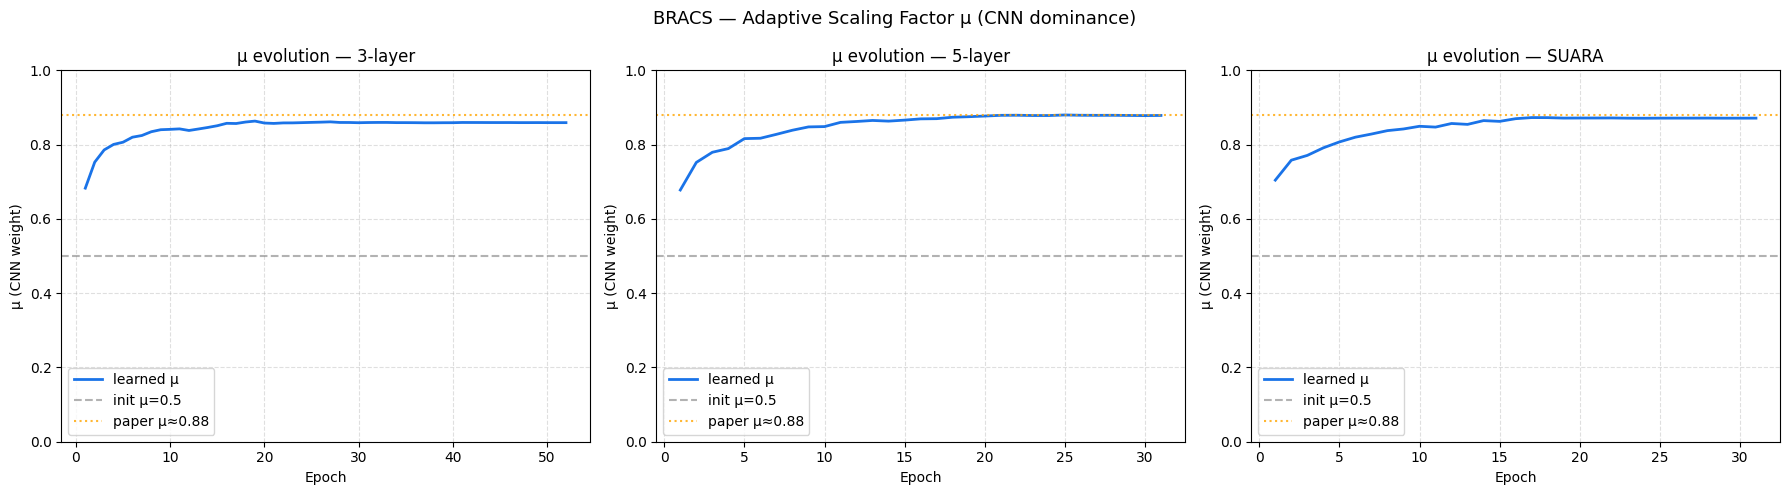

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, hist, name in [
    (axes[0], history_3layer, "3-layer"),
    (axes[1], history_5layer, "5-layer"),
    (axes[2], history_suara,  "SUARA"),
]:
    ax.plot(hist["epoch"], hist["mu"], color="#1a73e8", lw=2, label="learned μ")
    ax.axhline(0.5,  color="gray",   linestyle="--", alpha=0.6, label="init μ=0.5")
    ax.axhline(0.88, color="orange", linestyle=":",  alpha=0.8, label="paper μ≈0.88")
    ax.set_title(f"μ evolution — {name}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("μ (CNN weight)")
    ax.set_ylim(0, 1); ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
plt.suptitle("BRACS — Adaptive Scaling Factor μ (CNN dominance)", fontsize=13)
plt.tight_layout()
plt.savefig("bracs_mu_evolution_ver2.png", dpi=150, bbox_inches="tight")
plt.show()

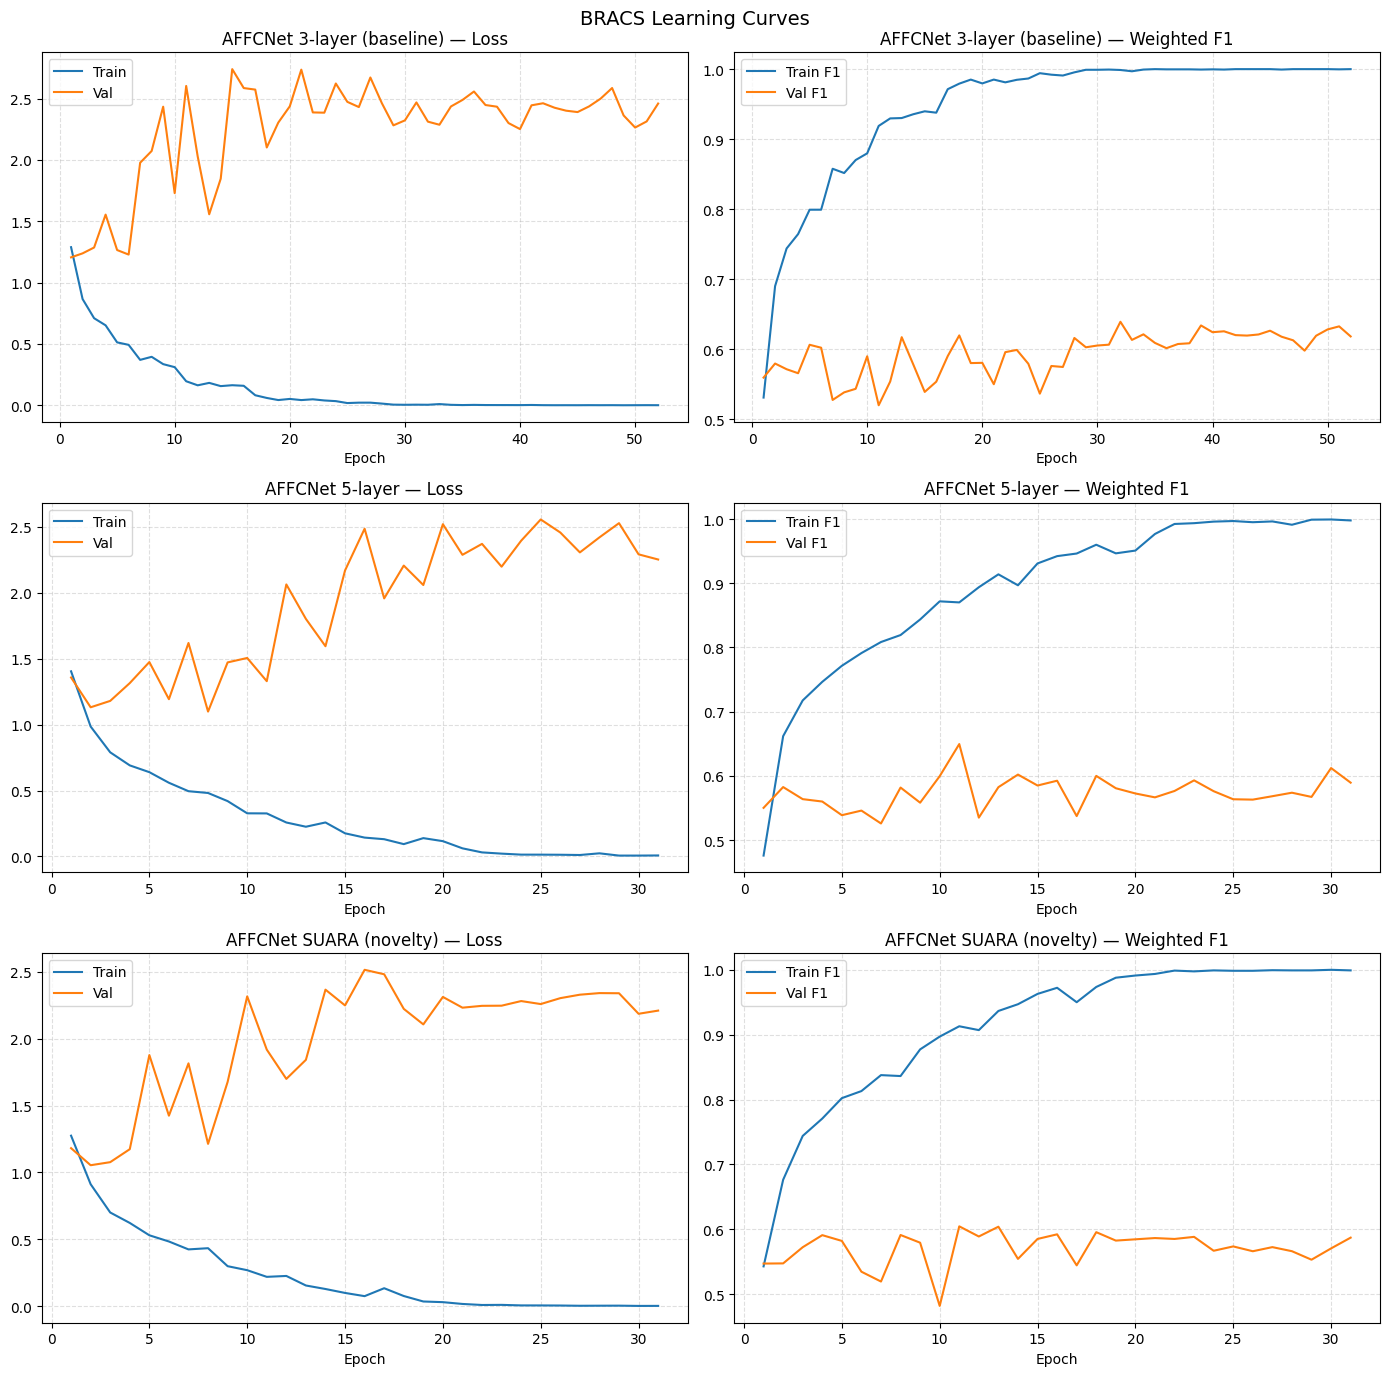

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for row, (hist, name) in enumerate([
    (history_3layer, "AFFCNet 3-layer (baseline)"),
    (history_5layer, "AFFCNet 5-layer"),
    (history_suara,  "AFFCNet SUARA (novelty)"),
]):
    axes[row, 0].plot(hist["epoch"], hist["train_loss"], label="Train")
    axes[row, 0].plot(hist["epoch"], hist["val_loss"],   label="Val")
    axes[row, 0].set_title(f"{name} — Loss")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].legend()
    axes[row, 0].grid(True, linestyle="--", alpha=0.4)

    axes[row, 1].plot(hist["epoch"], hist["train_f1"], label="Train F1")
    axes[row, 1].plot(hist["epoch"], hist["val_f1"],   label="Val F1")
    axes[row, 1].set_title(f"{name} — Weighted F1")
    axes[row, 1].set_xlabel("Epoch"); axes[row, 1].legend()
    axes[row, 1].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("BRACS Learning Curves", fontsize=14)
plt.tight_layout()
plt.savefig("bracs_learning_curves_ver2.png", dpi=150, bbox_inches="tight")
plt.show()

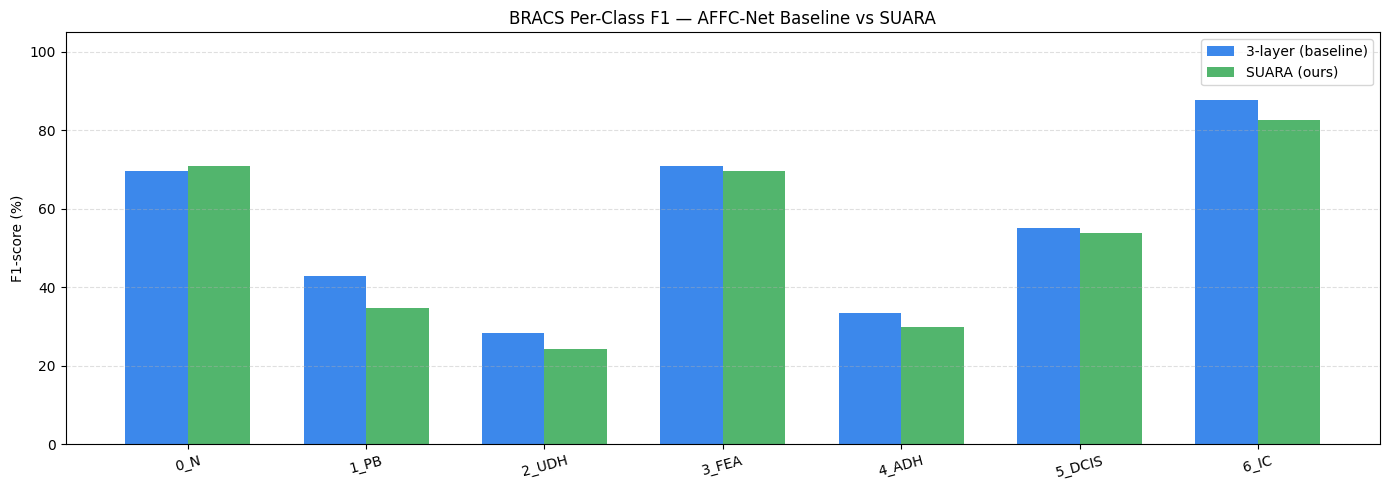

In [39]:
# Per-class F1 bar chart — 3-layer vs SUARA
x, width = np.arange(NUM_CLASSES), 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, test_3layer["per_class_f1"]*100, width, label="3-layer (baseline)", color="#1a73e8", alpha=0.85)
ax.bar(x + width/2, test_suara["per_class_f1"]*100,  width, label="SUARA (ours)",       color="#34a853", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_ylabel("F1-score (%)"); ax.set_ylim(0, 105)
ax.set_title("BRACS Per-Class F1 — AFFC-Net Baseline vs SUARA")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("bracs_per_class_f1_suara_ver2.png", dpi=150, bbox_inches="tight")
plt.show()

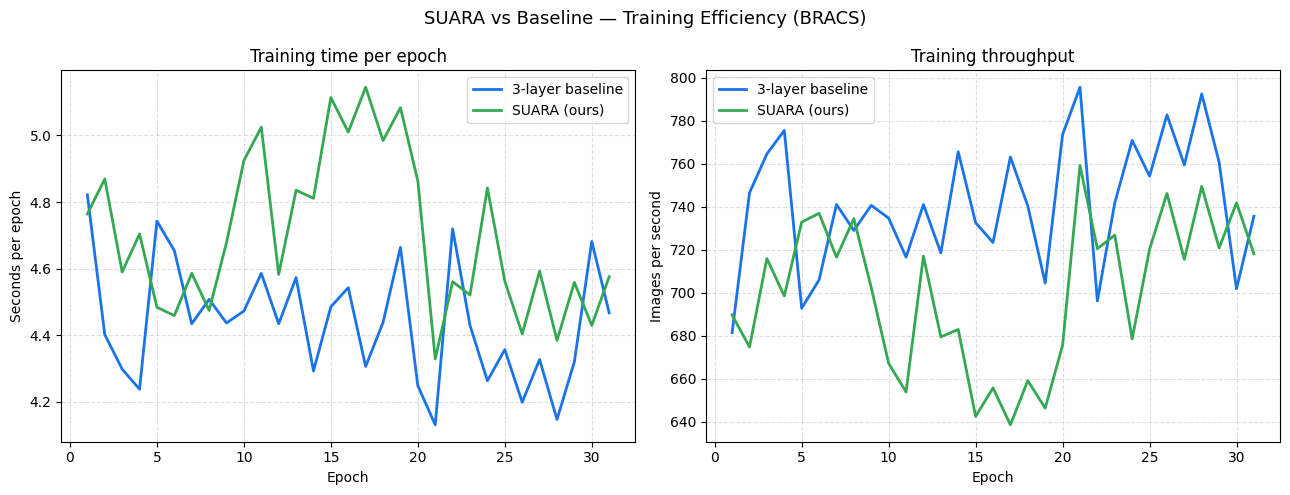

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, key, ylabel, title in [
    (axes[0], "epoch_time", "Seconds per epoch", "Training time per epoch"),
    (axes[1], "throughput", "Images per second",  "Training throughput"),
]:
    baseline_vals = history_3layer[key]
    suara_vals    = history_suara[key]
    min_ep = min(len(baseline_vals), len(suara_vals))
    epochs = list(range(1, min_ep + 1))
    ax.plot(epochs, baseline_vals[:min_ep], label="3-layer baseline", color="#1a73e8", lw=2)
    ax.plot(epochs, suara_vals[:min_ep],    label="SUARA (ours)",     color="#34a853", lw=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("SUARA vs Baseline — Training Efficiency (BRACS)", fontsize=13)
plt.tight_layout()
plt.savefig("bracs_suara_efficiency_ver2.png", dpi=150, bbox_inches="tight")
plt.show()

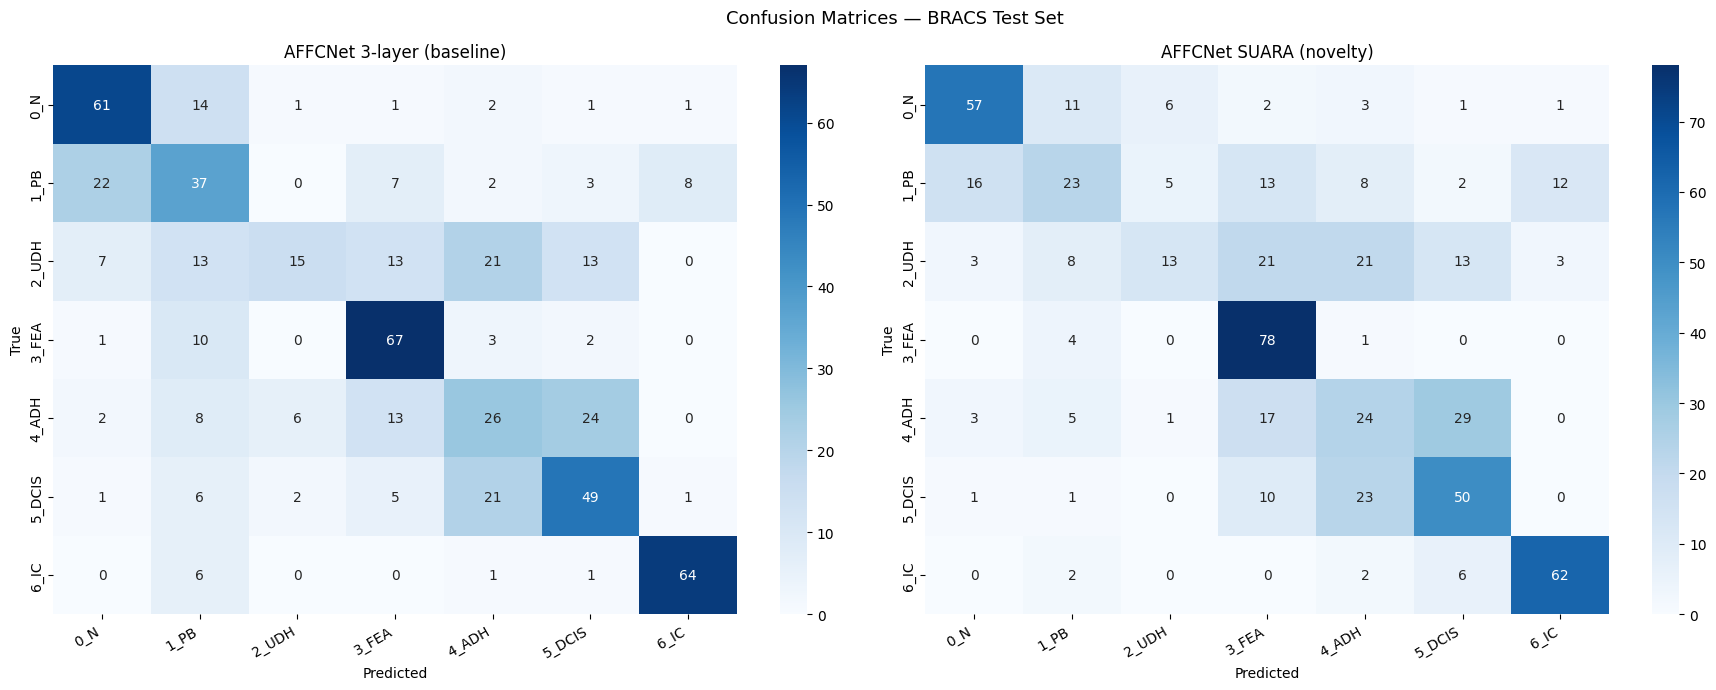

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, tm, title in [
    (axes[0], test_3layer, "AFFCNet 3-layer (baseline)"),
    (axes[1], test_suara,  "AFFCNet SUARA (novelty)"),
]:
    cm = tm["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.suptitle("Confusion Matrices — BRACS Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("bracs_confusion_matrices_ver2.png", dpi=150, bbox_inches="tight")
plt.show()

Task was destroyed but it is pending!
task: <Task pending name='Task-333' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /nfsshare/users/P126003189/.conda/envs/affc_env/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-334' coro=<_async_in_context.<locals>.preserve_context() running at /nfsshare/users/P126003189/.conda/envs/affc_env/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /nfsshare/users/P126003189/.conda/envs/affc_env/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/nfsshare/users/P126003189/.conda/envs/affc_env/lib/python3.10/site-packages/matplotlib/backend_bases.py:1730: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  super().__init__()  # Typically the GUI widget init (if any).
Task was destroyed but it is pending!
task: <Task pending name='Task-334' coro=<_async_in_context

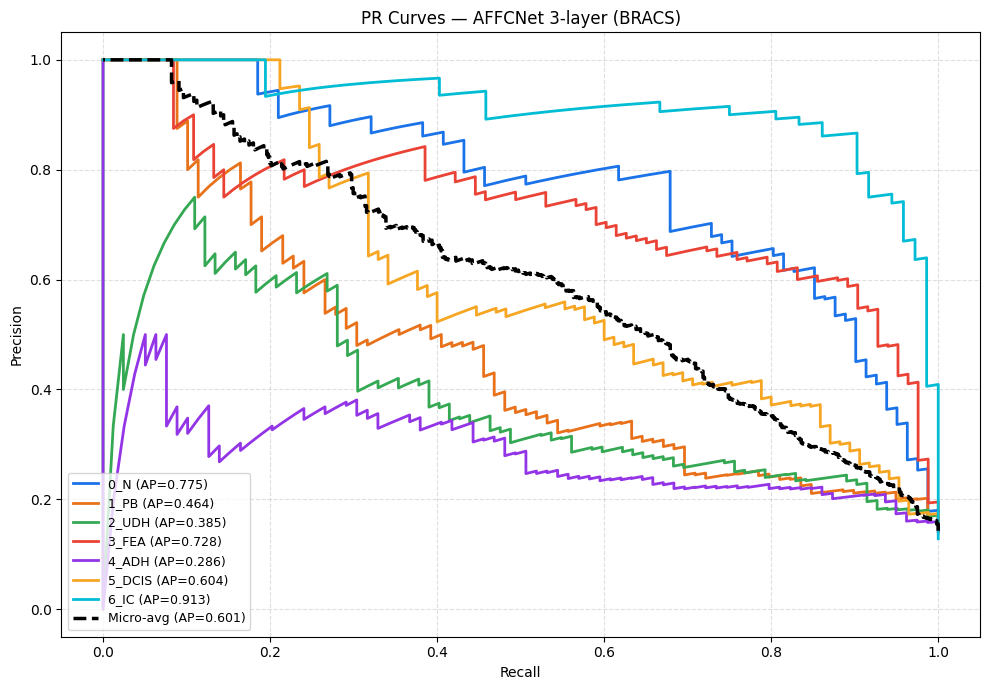

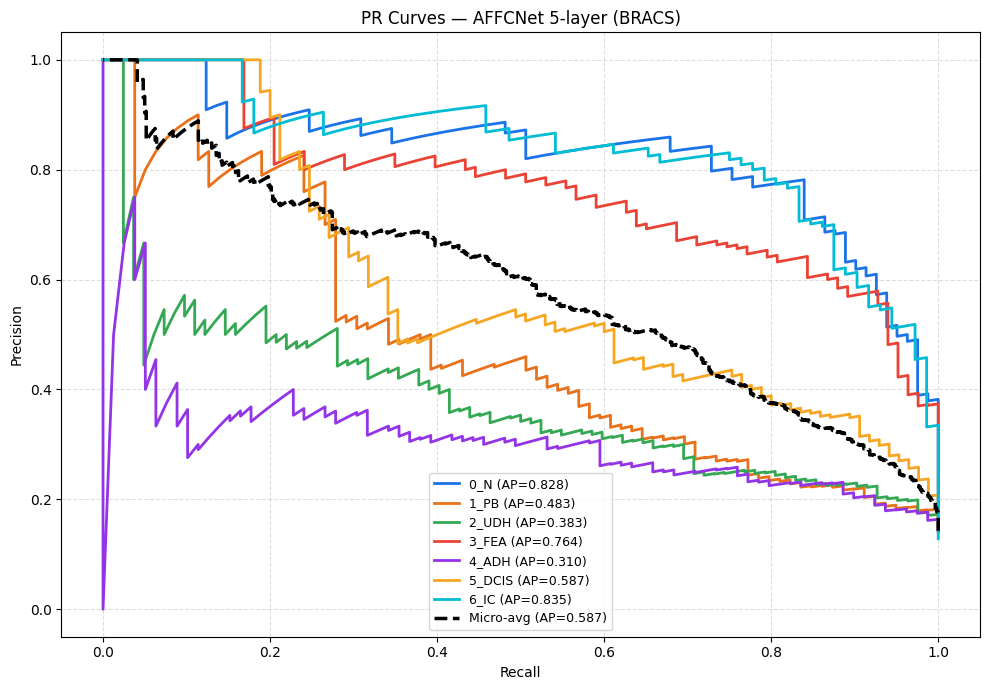

In [46]:
def plot_pr_curves(y_true, y_prob, title, save_name):
    y_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
    plt.figure(figsize=(10, 7))
    colors = ["#1a73e8","#e8711a","#34a853","#ea4335","#9334e6","#f6a623","#00bcd4"]
    for i, (cname, col) in enumerate(zip(CLASS_NAMES, colors)):
        p, r, _ = precision_recall_curve(y_bin[:, i], y_prob[:, i])
        ap = average_precision_score(y_bin[:, i], y_prob[:, i])
        plt.plot(r, p, lw=2, color=col, label=f"{cname} (AP={ap:.3f})")
    y_bin_r = y_bin.ravel(); prob_r = y_prob.ravel()
    p_m, r_m, _ = precision_recall_curve(y_bin_r, prob_r)
    micro_ap = average_precision_score(y_bin, y_prob, average="micro")
    plt.plot(r_m, p_m, "k--", lw=2.5, label=f"Micro-avg (AP={micro_ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(title); plt.legend(fontsize=9)
    plt.grid(True, linestyle="--", alpha=0.4); plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches="tight"); plt.show()

plot_pr_curves(test_3layer["y_true"], test_3layer["y_prob"],
               "PR Curves — AFFCNet 3-layer (BRACS)", "bracs_pr_3layer_ver2.png")
plot_pr_curves(test_5layer["y_true"], test_5layer["y_prob"],
               "PR Curves — AFFCNet 5-layer (BRACS)", "bracs_pr_5layer_ver2.png")


## Save all results

In [43]:
torch.save({
    # Test metrics
    "test_3layer": test_3layer, "test_5layer": test_5layer,
    "test_nognn":  test_nognn,  "test_noaff":  test_noaff,
    "test_suara":  test_suara,
    # Histories
    "history_3layer": history_3layer, "history_5layer": history_5layer,
    "history_nognn":  history_nognn,  "history_noaff":  history_noaff,
    "history_suara":  history_suara,
    # Split indices
    "train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx,
    "label_map": label_map,
    "class_names": CLASS_NAMES,
}, "bracs_affcnet_all_results_ver2.pt")

print("Saved → bracs_affcnet_all_results_ver2.pt")
print(f"\n{'Model':<28} {'F1':>8} {'Acc':>8}")
print("-" * 47)
for name, tm in [("3-layer (baseline)", test_3layer), ("SUARA (ours)", test_suara),
                 ("5-layer", test_5layer), ("no-GNN", test_nognn), ("no-AFF", test_noaff)]:
    print(f"{name:<28} {tm['weighted_f1']*100:>7.2f}%  {tm['accuracy']*100:>7.2f}%")
print(f"\nPaper target: Weighted F1=67.23%")

Saved → bracs_affcnet_all_results_ver2.pt

Model                              F1      Acc
-----------------------------------------------
3-layer (baseline)             55.03%    56.86%
SUARA (ours)                   51.90%    54.72%
5-layer                        53.43%    55.26%
no-GNN                         50.02%    50.80%
no-AFF                         51.17%    52.94%

Paper target: Weighted F1=67.23%


In [44]:
import json

def to_serializable(v):
    if isinstance(v, np.ndarray):  return v.tolist()
    if isinstance(v, torch.Tensor): return v.tolist()
    if isinstance(v, list):
        return [to_serializable(x) for x in v]
    if isinstance(v, dict):
        return {k2: to_serializable(v2) for k2, v2 in v.items()}
    return v

def get_max_grad_bytes(model):
    return max(p.numel() * 4 for p in model.parameters())

perf_export = {
    "ms_bytes": MS_BYTES,
    "max_grad_bytes_3layer": get_max_grad_bytes(trained_3layer),
    "max_grad_bytes_suara":  get_max_grad_bytes(trained_suara),

    "baseline_epoch_times": history_3layer["epoch_time"],
    "baseline_throughput":  history_3layer["throughput"],
    "baseline_best_f1":     float(best_f1_3layer),
    "baseline_test_f1":     float(test_3layer["weighted_f1"]),
    "baseline_test_acc":    float(test_3layer["accuracy"]),
    "baseline_test_prec":   float(test_3layer["precision_w"]),
    "baseline_test_recall": float(test_3layer["recall_w"]),
    "baseline_test_spec":   float(test_3layer["specificity_macro"]),

    "suara_epoch_times":    history_suara["epoch_time"],
    "suara_throughput":     history_suara["throughput"],
    "suara_best_f1":        float(best_f1_suara),
    "suara_test_f1":        float(test_suara["weighted_f1"]),
    "suara_test_acc":       float(test_suara["accuracy"]),
    "suara_test_prec":      float(test_suara["precision_w"]),
    "suara_test_recall":    float(test_suara["recall_w"]),
    "suara_test_spec":      float(test_suara["specificity_macro"]),

    "nognn_test_f1":  float(test_nognn["weighted_f1"]),
    "noaff_test_f1":  float(test_noaff["weighted_f1"]),
    "layer5_test_f1": float(test_5layer["weighted_f1"]),

    # Per-class F1 for comparison table
    "baseline_per_class_f1": test_3layer["per_class_f1"].tolist(),
    "suara_per_class_f1":    test_suara["per_class_f1"].tolist(),
    "class_names": CLASS_NAMES,
}

out_path = os.path.join(HOME, "bracs_affcnet_perf_stats_ver2.json")
with open(out_path, "w") as f:
    json.dump(to_serializable(perf_export), f, indent=2)

print(f"Exported → {out_path}")
print(f"  Baseline avg epoch time : {np.mean(history_3layer['epoch_time']):.2f}s")
print(f"  SUARA    avg epoch time : {np.mean(history_suara['epoch_time']):.2f}s")
print(f"  Speedup  (single GPU)   : {np.mean(history_3layer['epoch_time'])/np.mean(history_suara['epoch_time']):.2f}x")
print(f"  Baseline test F1        : {test_3layer['weighted_f1']*100:.2f}%")
print(f"  SUARA    test F1        : {test_suara['weighted_f1']*100:.2f}%")
print(f"  Improvement             : +{(test_suara['weighted_f1']-test_3layer['weighted_f1'])*100:.2f}%")

Exported → /nfsshare/users/P126003189/bracs_affcnet_perf_stats_ver2.json
  Baseline avg epoch time : 4.38s
  SUARA    avg epoch time : 4.70s
  Speedup  (single GPU)   : 0.93x
  Baseline test F1        : 55.03%
  SUARA    test F1        : 51.90%
  Improvement             : +-3.13%
